<a href="https://colab.research.google.com/github/cristian0527/MATH-383/blob/main/HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 3
### Cristian Castellanos
### Network Data

https://github.com/cristian0527/MATH-383/blob/main/HW3.ipynb

## Load packages

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np
import numpy.linalg as LA
import matplotlib as mpl
import matplotlib.cm as cm
import math
import requests
import json
from networkx.readwrite import json_graph
import pandas as pd
import csv
from sklearn.cluster import KMeans
from collections import Counter
from scipy.integrate import odeint
import itertools

## Problem 1
#### Dolphins Network

In [ ]:
# load dolphin network
loaded_matrix = np.loadtxt("./dolphins.csv", delimiter=",")
dolphin_graph_loaded = nx.from_numpy_array(loaded_matrix)

pos = nx.spring_layout(dolphin_graph_loaded, seed=67)

Problem 1A

Conditional on the number of nodes, dolphins, n, and the number of edges E in the dolphin network, the observed network is just a typical draw from the uniform distribution over all graphs with those features.

Problem 1B

Two network statistics I will use for comparison to the null distribution are the average clustering coefficient and the Average Degree.

I say that the cluestering coefficient will distinguish and the average degree will not distinguish.

Problem 1 computational components (C, D, E)

In [ ]:
n = dolphin_graph_loaded.number_of_nodes()
E = dolphin_graph_loaded.number_of_edges()

observed_clustering = nx.average_clustering(dolphin_graph_loaded)
observed_avg_degree = np.mean([deg for node, deg in dolphin_graph_loaded.degree()])
observed_path_length = nx.average_shortest_path_length(dolphin_graph_loaded)


samples = 1000
null_clustering = []
null_avg_degree = []
null_path_length = []

for i in range(samples):
    G_null = nx.gnm_random_graph(n, E)
    null_clustering.append(nx.average_clustering(G_null))
    degrees = [deg for node, deg in G_null.degree()]
    null_avg_degree.append(np.mean(degrees))

while len(null_path_length) < samples:
    G_null = nx.gnm_random_graph(n, E)
    if nx.is_connected(G_null):
        null_path_length.append(nx.average_shortest_path_length(G_null))

Ran this with Grace. Very interesting because we both assumed our observed would fall in the null distribution; however, it is statistically significant.

Why is that the case?

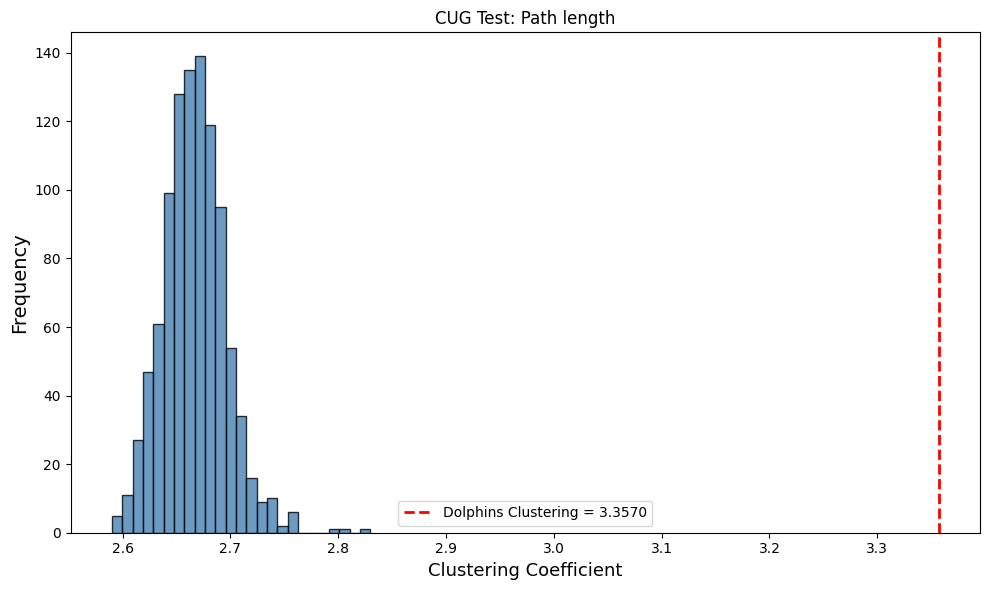

In [ ]:
# path length
plt.figure(figsize=(10, 6))
plt.hist(null_path_length, bins=25, color='steelblue', edgecolor='black', alpha=0.8)
plt.axvline(observed_path_length, color='red', linestyle='dashed', linewidth=2, label=f'Dolphins Clustering = {observed_avg_path:.4f}')
plt.title("CUG Test: Path length")
plt.xlabel('Clustering Coefficient', fontsize=13)
plt.ylabel("Frequency", fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# p-values
p_value_clustering = np.mean(np.array(null_clustering) >= observed_clustering)
p_value_avg_degree = np.mean(np.array(null_avg_degree) >= observed_avg_degree)

print(f"P-value for Clustering Coefficient: {p_value_clustering}")
print(f"P-value for Average Degree: {p_value_avg_degree}")

P-value for Clustering Coefficient: 0.0
P-value for Average Degree: 1.0


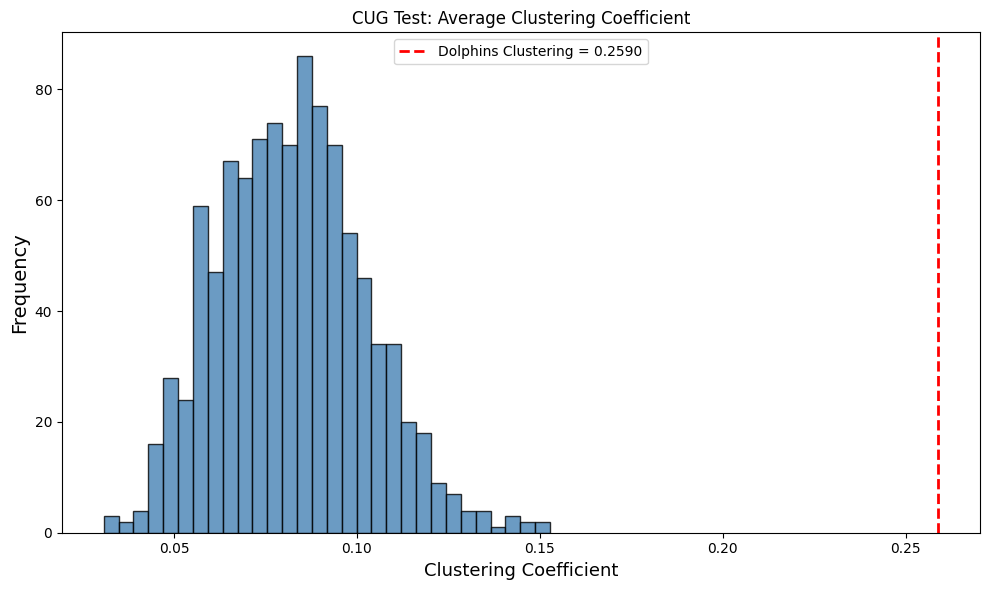

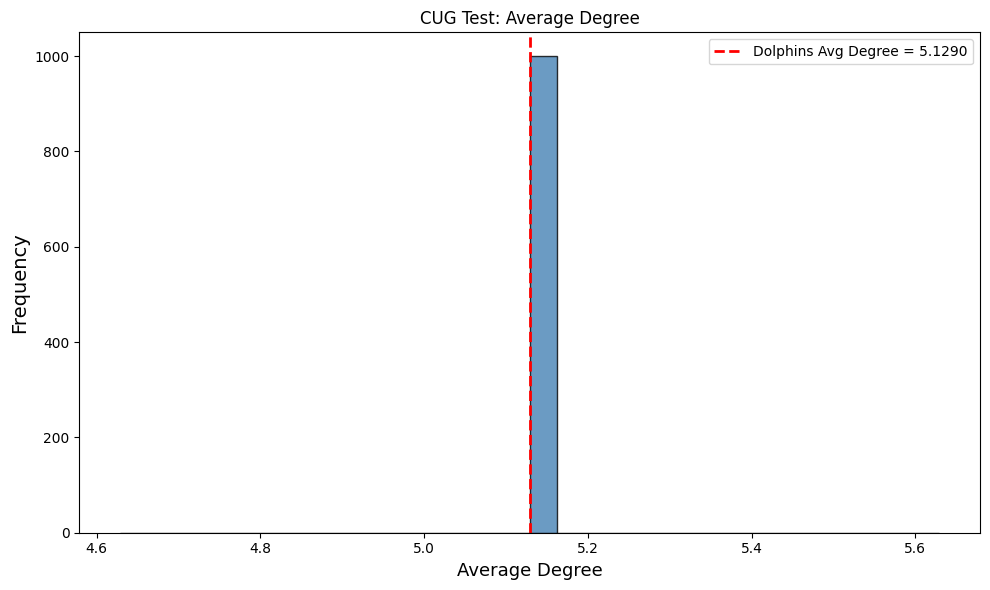

In [ ]:
# clustering coefficient grph
plt.figure(figsize=(10, 6))
plt.hist(null_clustering, bins=30, color='steelblue', edgecolor='black', alpha=0.8)
plt.axvline(observed_clustering, color='red', linestyle='dashed', linewidth=2, label=f'Dolphins Clustering = {observed_clustering:.4f}')
plt.title("CUG Test: Average Clustering Coefficient")
plt.xlabel('Clustering Coefficient', fontsize=13)
plt.ylabel("Frequency", fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

# average degree grph
plt.figure(figsize=(10, 6))
plt.hist(null_avg_degree, bins=30, color='steelblue', edgecolor='black', alpha=0.8)
plt.axvline(observed_avg_degree, color='red', linestyle='dashed', linewidth=2, label=f'Dolphins Avg Degree = {observed_avg_degree:.4f}')
plt.title("CUG Test: Average Degree")
plt.xlabel('Average Degree', fontsize=13)
plt.ylabel("Frequency", fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

Problem 1f

The clustering coefficient did distuinguish the dolphins network from the null model. The observed value of 0.259 falls far to the right of the entire null distribution, with a reported p-value of 0, which means none of the 1000 generated graphs had a clustering as high as the dolphins network. Confirms that the dolphins network has significantly more clustering than a randomly generated network with the same n and E, which makes sense because real social networks have this underlying philosophy where friends of friends may be friends.

The average degree was totally expected. The p-value that was reported is 1. This makes sense becayse the average degree is just 2E/n. Since E and n are fixed, every randomly generated network will have the same avergae degree.

## Problem 2
#### Markov Chain

Problem 2a

The edge toggle procedure defines a Markov chain on the state space of networks on the vertex set {1,2,...,n} because the next state (the following graph after the toggling) depends only on the current graph and not any previous graphs visited. At each step, we randomly select one of the (n 2) edges and toggle it, which is based on the current edges of the graph. Therefore, since the transition probabilities depend only on the current graph we are in, and not the path that led up to where we are, this satisfies the property of a Markov chain.

Problem 2b

The edge toggle Markov chain is irreducible on the state space of networks on the vertex set {1,2,...,n}. Suppose we have any two graphs, G1 and G2, in our Markov chain. At most, the difference in the number of edges between these two states is n choose k apart. So, through the process of randomly picking any pair of nodes and toggle the edge between them, and iteratively do this with the edges that lay between G1 and G2, we would get a path that would connect the two.

Problem 2c

With a 1/2 probability of a graph remaining in place (self-loop) or doing an  edge toggle step, the GCD of the lengths all cycles is 1 because there is no certainty of a pattern occurring. This 1/2 probability allows for self-loops (return to the current state by doing nothing), or return in n steps back to that state through iterative processes of toggling an edge and or staying.

Problem 2d

π = Pπ: Simulated stationary distribution of lazy Markov chain on a graph with n=4 and over 7500 steps. At each step, the chain either stays in place or toggles a randomly chosen edge, both with 1/2 probability.

After tracking, I divided the visit counts by the total number of steps, and obtained the probabilities for each graph visited. I took the mean to get an estimate of the stationary distribution, which resulted with π(G) = 0.015625

In [ ]:
from itertools import combinations

n = 4
possible_edges = list(combinations(range(n), 2))
num_edges = len(possible_edges) # n choose 2

state = [0] * num_edges

num_steps = 7500
visit_counts = {}

for i in range(num_steps):
    # lazy step
    if np.random.rand() < 0.5:
        # toggle a random edge
        j = np.random.randint(num_edges)
        state[j] = 1 - state[j]

    s = tuple(state)
    visit_counts[s] = visit_counts.get(s, 0) + 1

#visit_counts

probabilities = np.array(list(visit_counts.values())) / num_steps
probabilities.mean()

np.float64(0.015625)

## Problem 3
#### Markov Chain, with fix n = 10

Problem 3a

In [ ]:
n = 10

def score(G, beta):
    num_triangles = sum(nx.triangles(G).values()) / 3
    return math.exp(beta * num_triangles)


def metropolis_hastings(n, beta, steps):
    # start with empty graph
    G = nx.Graph()
    G.add_nodes_from(range(n))

    nlist = list(G.nodes())
    triangle_counts = []
    edge_counts = []

    for step in range(steps):
        # propose new graph via edge toggle
        endpoints = random.sample(nlist, k=2)
        G_hat = G.copy()

        if G_hat.has_edge(endpoints[0], endpoints[1]):
            G_hat.remove_edge(endpoints[0], endpoints[1])
        else:
            G_hat.add_edge(endpoints[0], endpoints[1])

        # acceptance ratio
        alpha = min(1, score(G_hat, beta) / score(G, beta))

        # accept or reject
        if random.random() < alpha:
            G = G_hat

        # record statistics
        triangle_counts.append(sum(nx.triangles(G).values()) / 3)
        edge_counts.append(G.number_of_edges())

    return triangle_counts, edge_counts

Problem 3b

In [ ]:
betas = [0, 0.3, 0.6, 1]
steps = 10000
results = {}

for beta in betas:
    triangles, edges = metropolis_hastings(n, beta, steps)
    results[beta] = {'triangles': triangles, 'edges': edges}

Problem 3c

As Beta increased, both the expected number of triangles and the expected number of edges increased significantly. Though from 0.6 to 1, the values barely change, suggesting we are close to a graph where there is little room for growth

In [66]:
for beta in betas:
    exp_triangles = sum(results[beta]['triangles']) / steps
    exp_edges = sum(results[beta]['edges']) / steps
    print(f"Beta={beta} -> E[triangles]={exp_triangles:.4f} & E[edges]={exp_edges:.4f}")


Beta=0 -> E[triangles]=14.7465 & E[edges]=22.4398
Beta=0.3 -> E[triangles]=71.4821 & E[edges]=37.3979
Beta=0.6 -> E[triangles]=115.6448 & E[edges]=44.3459
Beta=1 -> E[triangles]=119.1098 & E[edges]=44.8110


Problem 3d

For B = 0.5, after running two chains (one starting from empty graph and the other on the complete graph) for 10000 steps, we see that the empty graph converges with both the triangle and edge graph. Both chains fluctuate at around the same values too.

So, I would say 10000 steps is enough for effective sampling

In [73]:
def metropolis_hastings_graph(n, beta, steps, start='empty'):
    G = nx.Graph()
    G.add_nodes_from(range(n))

    if start == 'complete':
        for i in range(n):
            for j in range(i+1, n):
                G.add_edge(i, j)

    nodes = list(G.nodes())
    triangle_counts = []
    edge_counts = []

    for step in range(steps):
        endpoints = random.sample(nodes, k=2)
        G_hat = G.copy()

        if G_hat.has_edge(endpoints[0], endpoints[1]):
            G_hat.remove_edge(endpoints[0], endpoints[1])
        else:
            G_hat.add_edge(endpoints[0], endpoints[1])

        alpha = min(1, score(G_hat, beta) / score(G, beta))

        if random.random() < alpha:
            G = G_hat

        triangle_counts.append(sum(nx.triangles(G).values()) / 3)
        edge_counts.append(G.number_of_edges())

    return triangle_counts, edge_counts

In [69]:
beta = 0.5
steps = 10000

triangles_empty, edges_empty = metropolis_hastings_init(n, beta, steps, start='empty')
triangles_complete, edges_complete = metropolis_hastings_init(n, beta, steps, start='complete')

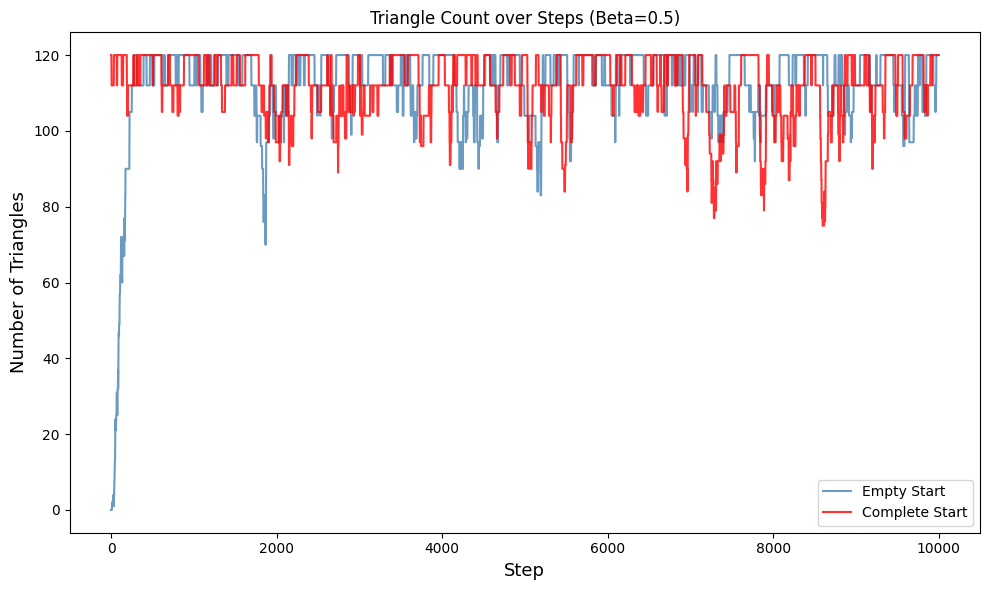

In [71]:
# triangles
plt.figure(figsize=(10, 6))
plt.plot(triangles_empty, color='steelblue', alpha=0.8, label='Empty Start')
plt.plot(triangles_complete, color='red', alpha=0.8, label='Complete Start')
plt.title(f'Triangle Count over Steps (Beta={beta})')
plt.xlabel('Step', fontsize=13)
plt.ylabel('Number of Triangles', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

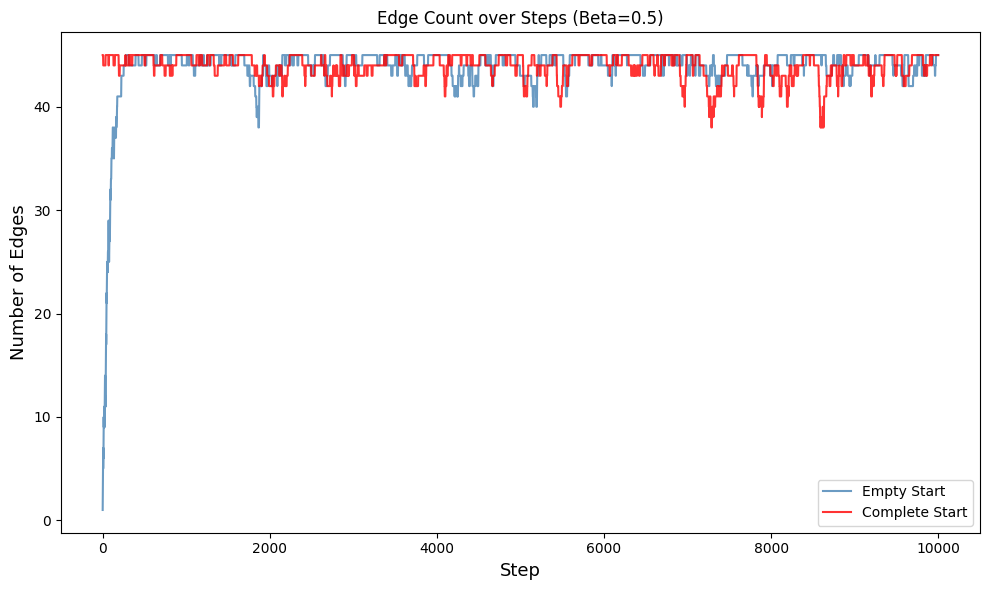

In [72]:
# edges
plt.figure(figsize=(10, 6))
plt.plot(edges_empty, color='steelblue', alpha=0.8, label='Empty Start')
plt.plot(edges_complete, color='red', alpha=0.8, label='Complete Start')
plt.title(f'Edge Count over Steps (Beta={beta})')
plt.xlabel('Step', fontsize=13)
plt.ylabel('Number of Edges', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

## Problem 4
#### Sophisticated Dolphin Network Comparison

In [75]:
def metropolis_hastings_edge_swap(G_swap, beta, steps):
    G = G_swap.copy()
    nlist = list(G.nodes())

    triangle_counts = []
    edge_counts = []
    clustering_counts = []

    for step in range(steps):
        edges = list(G.edges())
        non_edges = list(nx.non_edges(G))

        # need at least one edge & one non-edge to swap
        if len(edges) == 0 or len(non_edges) == 0:
            continue

        # pick a random existing edge e and random non-edge f
        e = random.choice(edges)
        f = random.choice(non_edges)

        # propose G' = G - e + f
        G_hat = G.copy()
        G_hat.remove_edge(e[0], e[1])
        G_hat.add_edge(f[0], f[1])

        # acceptance ratio
        alpha = min(1, score(G_hat, beta) / score(G, beta))

        # accept or reject
        if random.random() < alpha:
            G = G_hat

        triangle_counts.append(sum(nx.triangles(G).values()) / 3)
        edge_counts.append(G.number_of_edges())
        clustering_counts.append(nx.average_clustering(G))

    return triangle_counts, edge_counts, clustering_counts

Computationally expensive...
Pretty sure it's O(steps(n^2)) ...

In [76]:
betas = [0, 0.3, 0.6, 1]
steps = 10000
results_ = {}

for beta in betas:
    triangles, edges, clustering = metropolis_hastings_edge_swap(dolphin_graph_loaded, beta, steps)

   # p values
    p_clustering = np.mean(np.array(clustering) >= observed_clustering)
    p_avg_degree = np.mean(np.array(edges) >= observed_avg_degree * dolphin_graph_loaded.number_of_nodes() / 2)

    results_[beta] = {
        'triangles': triangles,
        'edges': edges,
        'clustering': clustering,
        'p_clustering': p_clustering,
        'p_avg_degree': p_avg_degree
    }
    print(f"Beta={beta} -> p-value clustering={p_clustering:.4f} & p-value avg degree={p_avg_degree:.4f}")

Beta=0 -> p-value clustering=0.0000 & p-value avg degree=1.0000
Beta=0.3 -> p-value clustering=0.0013 & p-value avg degree=1.0000
Beta=0.6 -> p-value clustering=0.0001 & p-value avg degree=1.0000
Beta=1 -> p-value clustering=0.4527 & p-value avg degree=1.0000


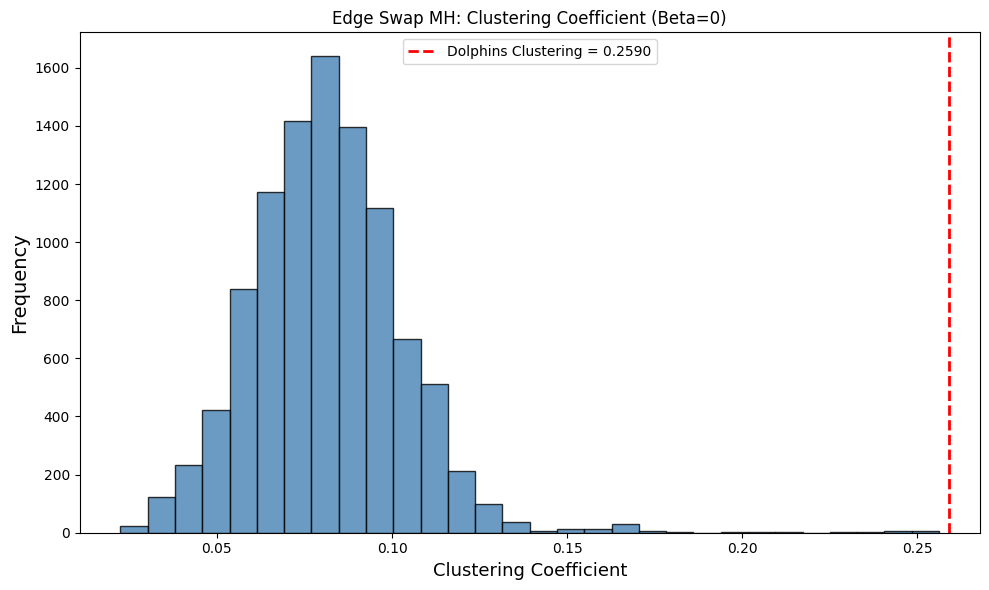

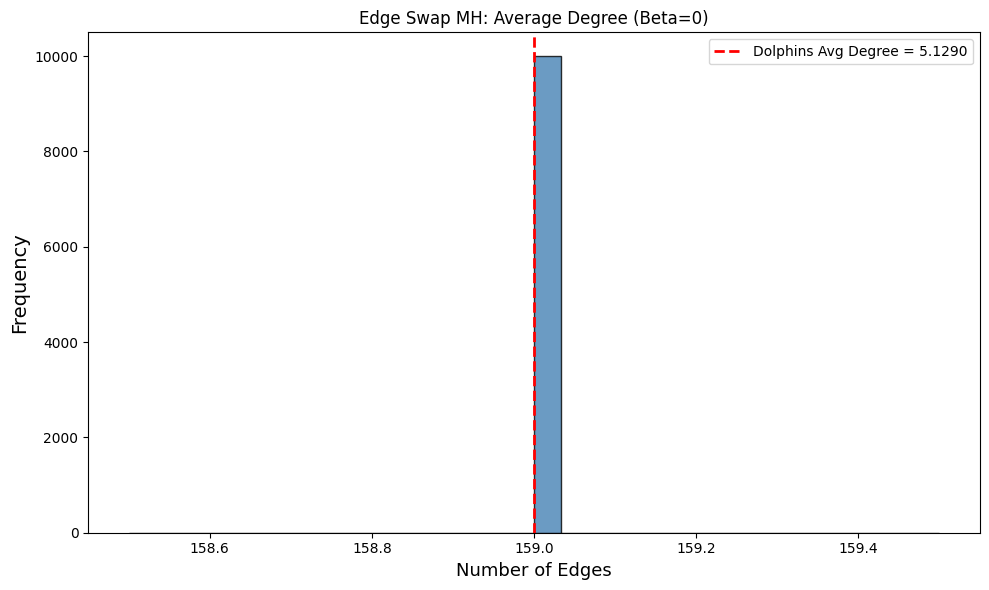

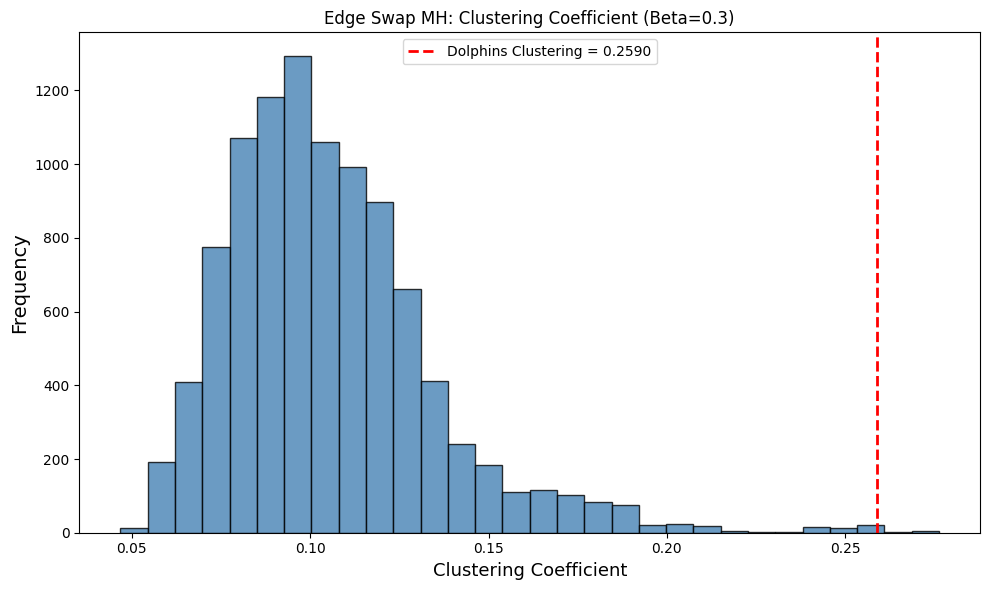

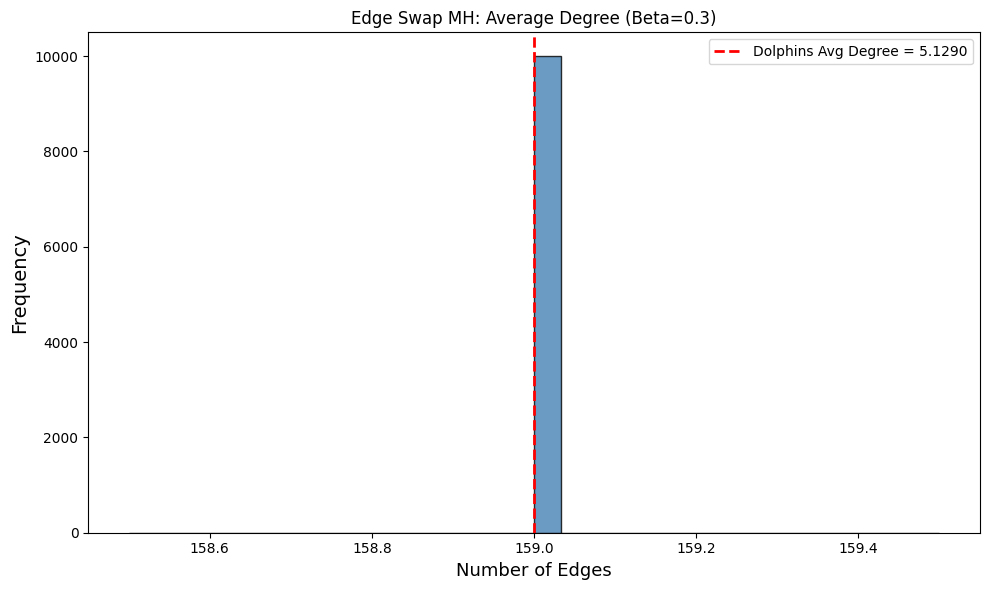

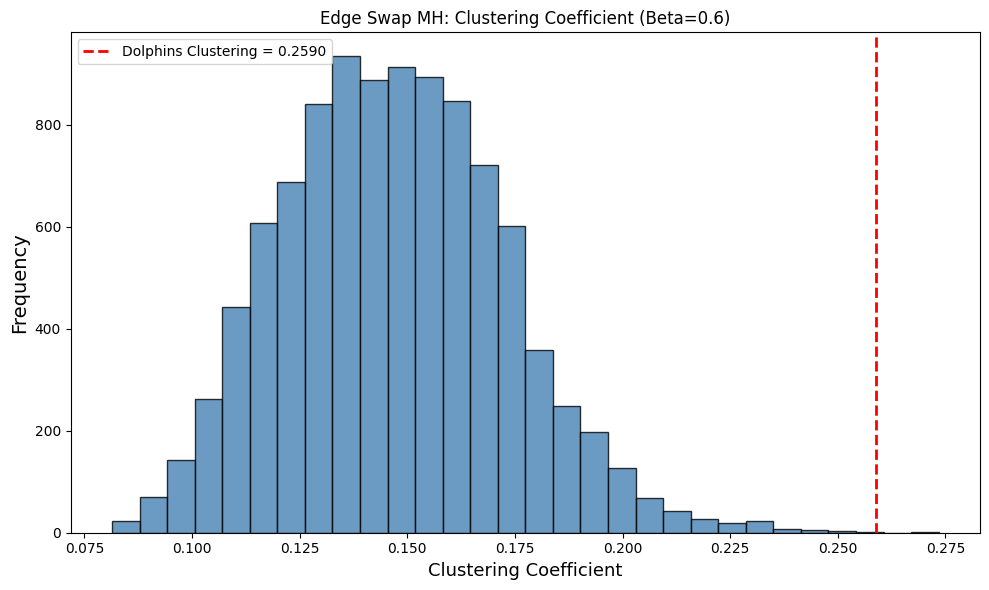

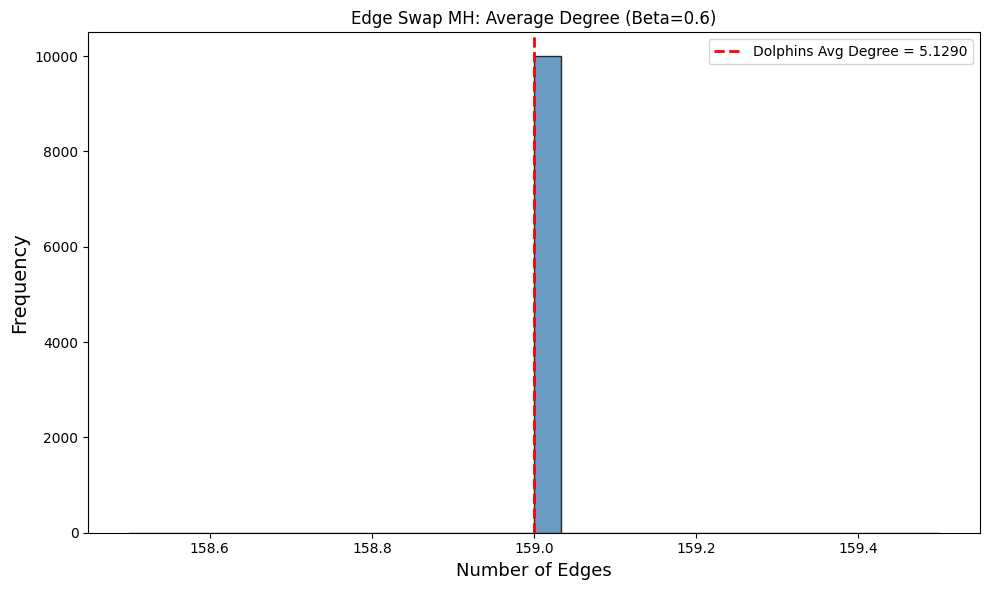

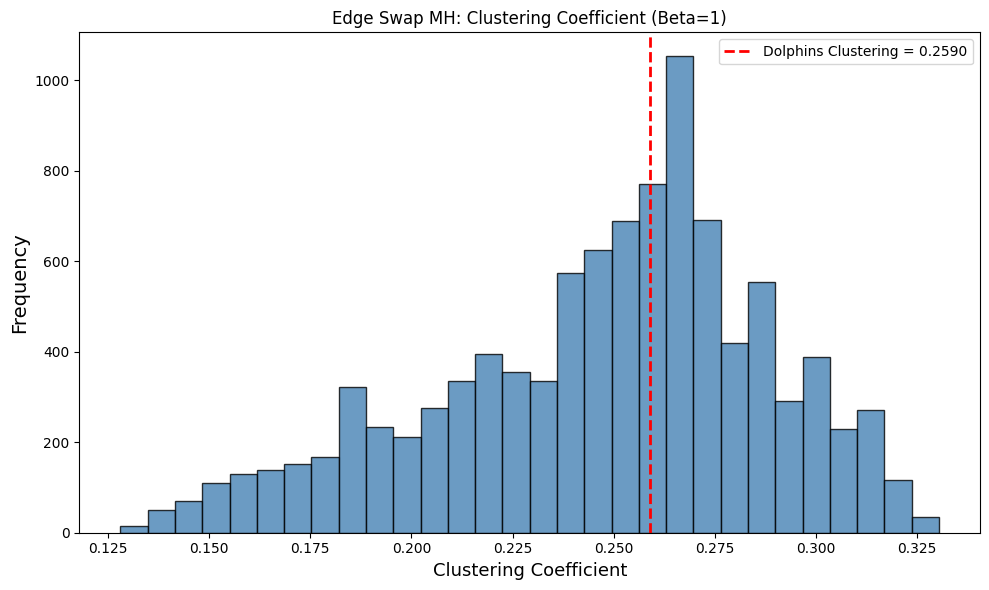

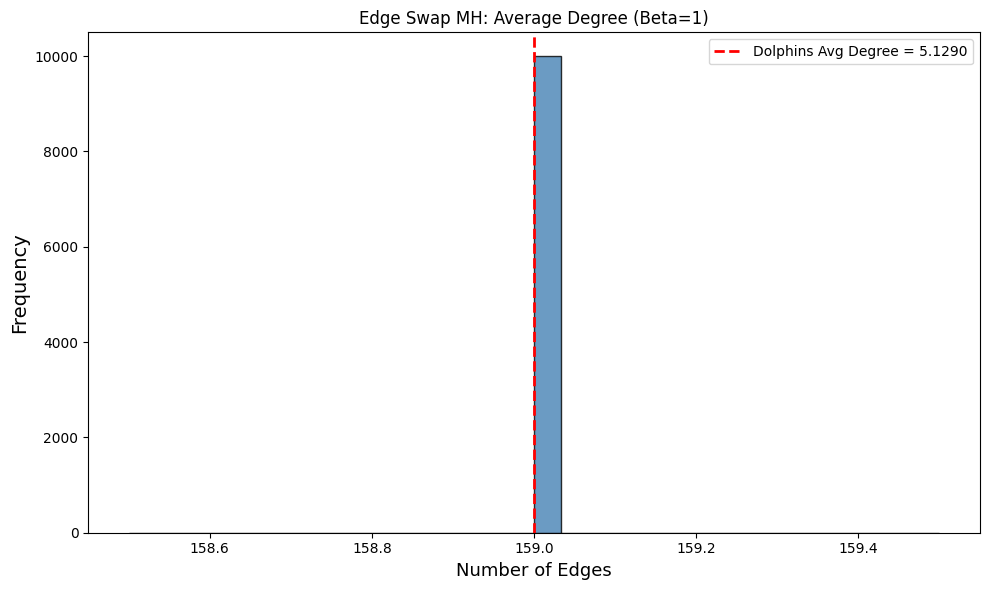

In [78]:
for beta in betas:
    # clustering coefficient
    plt.figure(figsize=(10, 6))
    plt.hist(results_[beta]['clustering'], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
    plt.axvline(observed_clustering, color='red', linestyle='dashed', linewidth=2,
                label=f'Dolphins Clustering = {observed_clustering:.4f}')
    plt.title(f'Edge Swap MH: Clustering Coefficient (Beta={beta})')
    plt.xlabel('Clustering Coefficient', fontsize=13)
    plt.ylabel('Frequency', fontsize=14)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # average degree
    plt.figure(figsize=(10, 6))
    plt.hist(results_[beta]['edges'], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
    plt.axvline(observed_avg_degree * dolphin_graph_loaded.number_of_nodes() / 2,
                color='red', linestyle='dashed', linewidth=2,
                label=f'Dolphins Avg Degree = {observed_avg_degree:.4f}')
    plt.title(f'Edge Swap MH: Average Degree (Beta={beta})')
    plt.xlabel('Number of Edges', fontsize=13)
    plt.ylabel('Frequency', fontsize=14)
    plt.legend()
    plt.tight_layout()
    plt.show()


Results from part 1:

P-value for Clustering Coefficient: 0.0
P-value for Average Degree: 1.0

Looking at the results from Metropolis-Hastings procedure to sample from the distribution proportional to this score function, with Betas {0, 0.3, 0.6, 1}, we can see that as Beta increases, the p-value increases. Also, as B increases, the null distribution shifts toward our observed clustering coefficient. At B=1, our p value says that our dolphins network is no longer distinguishable from the null.

Ultimately, our insights suggest that our network may be explained by the formation of triangles.

For the average degree though, that stayed the same. This isnt surprising because the number of edges kept fixed with one being removed + one being added.